In [1]:
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import export_graphviz

import pandas as pd
from sklearn.preprocessing import LabelEncoder
import graphviz


In [2]:
def importdata(path='D:\\New folder\\PlayTennis.csv'):
    data = pd.read_csv(path, header=0, skiprows=0)
    print("Dataset Length: ", len(data))
    print("Dataset Shape: ", data.shape)
    # data.target = data['play']
    
    return data
    
playtennis_data = importdata()


Dataset Length:  14
Dataset Shape:  (14, 5)


In [4]:
playtennis_data

,Outlook,Temperature,Humidity,Wind,Play Tennis
0,Sunny,Hot,High,Weak,No
1,Sunny,Hot,High,Strong,No
2,Overcast,Hot,High,Weak,Yes
3,Rain,Mild,High,Weak,Yes
4,Rain,Cool,Normal,Weak,Yes
5,Rain,Cool,Normal,Strong,No
6,Overcast,Cool,Normal,Strong,Yes
7,Sunny,Mild,High,Weak,No
8,Sunny,Cool,Normal,Weak,Yes
9,Rain,Mild,Normal,Weak,Yes


In [5]:
# Creating a Label encoder to convert text to numbers
Le = LabelEncoder()

playtennis_data['Outlook'] = Le.fit_transform(playtennis_data['Outlook'])
playtennis_data['Temperature'] = Le.fit_transform(playtennis_data['Temperature'])
playtennis_data['Humidity'] = Le.fit_transform(playtennis_data['Humidity'])
playtennis_data['Wind'] = Le.fit_transform(playtennis_data['Wind'])
playtennis_data['Play Tennis'] = Le.fit_transform(playtennis_data['Play Tennis'])

X = playtennis_data[['Outlook', 'Temperature', 'Humidity', 'Wind']]
y = playtennis_data['Play Tennis']


In [6]:
# Create the classifier and train it
tree = DecisionTreeClassifier(criterion='entropy', random_state=0)
tree.fit(X, y)


DecisionTreeClassifier(criterion='entropy', random_state=0)

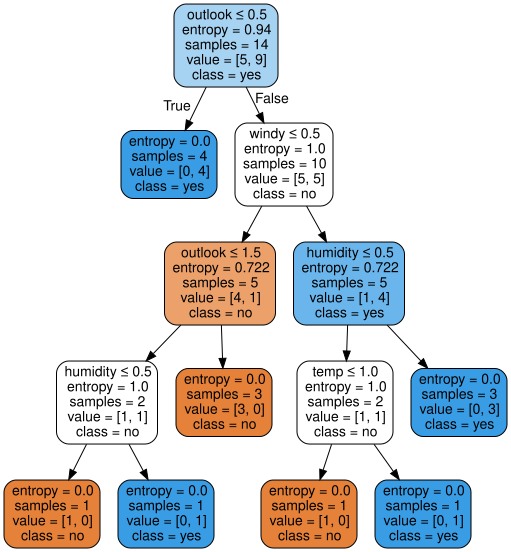

In [7]:
dot_data = export_graphviz(tree, out_file=None)
graph = graphviz.Source(dot_data)
graph.render("iris")

dot_data = export_graphviz(tree, out_file=None, feature_names=['outlook', 'temp', 'windy', 'humidity'], 
                           class_names=['no', 'yes'], filled=True, rounded=True, special_characters=True)
graph = graphviz.Source(dot_data)

graph


##############################################################################################

In [16]:
playtennis_data.columns

Index(['Outlook', 'Temperature', 'Humidity', 'Wind', 'Play Tennis'], dtype='object')

In [24]:
import numpy as np
import pandas as pd

def importdata(path='D:\\New folder\\PlayTennis.csv'):
    # Import data from CSV
    data = pd.read_csv(path, header=0)
    print("Dataset Length: ", len(data))
    print("Dataset Shape: ", data.shape)
    
    # Define 'Play Tennis' as the target variable
    return data

def values(data):
    # Function to get all unique values in a column
    return data.unique()

def Entropy(data, target_column):
    # Calculate entropy for the target variable
    value_counts = data[target_column].value_counts()
    entropy = 0
    total_count = len(data)
    for count in value_counts:
        p = count / total_count
        entropy -= p * np.log2(p)
    return entropy

def IG(data, feature, target_column):
    # Information Gain (IG) calculation
    base_entropy = Entropy(data, target_column)  # Entropy of the entire dataset
    feature_values = values(data[feature])  # Get all unique values of the feature
    feature_entropy = 0
    total_count = len(data)

    for value in feature_values:
        subset = data[data[feature] == value]  # Subset of data where feature equals this value
        feature_entropy += (len(subset) / total_count) * Entropy(subset, target_column)
    
    return base_entropy - feature_entropy  # Information Gain = Base entropy - Feature entropy

class Node:
    def __init__(self, name=None, attr=None, leaf_value=None):
        self.name = name  # The feature that is tested at this node
        self.attr = attr  # List of attributes to split on
        self.leaf_value = leaf_value  # For leaf nodes, the value (class label)

    def call_(self):
        return self.name

def DTNode(data, features_used, target_column):
    node = Node()
    max_ig = -float('inf')  # Information Gain (IG) starts with a very low value
    best_feature = None

    # Go through all features except the target column
    val_list = [v for v in data.columns if v != target_column and v not in features_used]
    
    if not val_list:  # If there are no features left to split on
        return None

    for feature in val_list:
        ig = IG(data, feature, target_column)  # Calculate Information Gain for each feature
        if ig > max_ig:  # Update the best feature with the highest Information Gain
            max_ig = ig
            best_feature = feature

    if best_feature:
        features_used.append(best_feature)  # Add this feature to the list of used features
        node.name = best_feature
        node.attr = values(data[best_feature])  # Get all unique values of this feature

        return node
    else:
        return None

def DTClassifier(data, features_used, target_column):
    root = DTNode(data, features_used, target_column)
    
    tree = {}  # Dictionary to store the decision tree structure

    if root:
        items = []
        for value in root.attr:  # For each value of the best feature
            subset = data[data[root.name] == value]  # Subset of data for this value
            if Entropy(subset, target_column) == 0:  # If the subset is pure (entropy = 0)
                # Assign the class label for this subset
                items.append((value, subset[target_column].iloc[0]))
            else:
                dt = DTClassifier(subset, features_used, target_column)  # Recursive call to build the tree
                items.append((value, dt))

        tree[root.name] = items  # Store the tree

    return tree

def main():
    # Import data
    data = importdata('D:\\New folder\\PlayTennis.csv')
    
    # Assuming 'Play Tennis' is the target variable column
    target_column = 'Play Tennis'

    # Train decision tree
    features_used = []  # List of features already used in the tree
    tree = DTClassifier(data, features_used, target_column)

    # Print the decision tree
    print("Generated Decision Tree: ")
    print(tree)

if __name__ == '__main__':
    main()


Dataset Length:  14
Dataset Shape:  (14, 5)
Generated Decision Tree: 
{'Outlook': [('Sunny', {'Humidity': [('High', 'No'), ('Normal', 'Yes')]}), ('Overcast', 'Yes'), ('Rain', {'Wind': [('Weak', 'Yes'), ('Strong', 'No')]})]}
